# Preprocessing EDA

Cross-platform spatial proteomics preprocessing, mirroring the **Risom et al. 2026**
MIBI pipeline:

1. **Cell size normalization** — scale each cell's mean marker intensity by cell area
   (→ per-pixel intensity), removing cell-size bias.
2. **Variance stabilization** — `arcsinh(x / cofactor)`.
3. **Winsorization** — cap each marker at its 99.9th percentile to suppress antibody aggregates.
4. **0–1 normalization** — per-marker min-max scaling for cross-dataset comparability.

> **Divergence from Risom:** Risom scales by area *and then multiplies by the dataset
> mean cell area*. We omit the mean-area rescale — Patwa's published matrix is already
> per-pixel with no area column to recover the constant, so for consistency no dataset
> gets it. The omission is a global multiplicative factor absorbed by the arcsinh
> cofactor; it can be reinstated per-dataset later. Risom also uses 0–1 normalization
> (not z-score), which we follow.

**Layer scheme** (`X` stays raw throughout):

| Layer | Contents |
|---|---|
| `X` | raw (untouched) |
| `layers["size_norm"]` | step 1 output (Schurch only — the only raw dataset with an area column) |
| `layers["exprs"]` | step 2 output, winsorized in place at step 3 |
| `layers["exprs_norm"]` | step 4 output — **final modeling layer** |

> All datasets held in-memory as `adatas`. No files written until the strategy is finalized.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
_r = next(p for p in [Path().resolve(), *Path().resolve().parents] if (p / 'data').is_dir() and (p / 'notebooks').is_dir())
if str(_r) not in sys.path: sys.path.insert(0, str(_r))

import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
from IPython.display import display

from data.EDA import (
    KEREN_CFG, SCHURCH_CFG, PATWA_CFG, JACKSON_CFG, shared_markers,
)
from data.preprocessing import (
    expression_stats, expression_stats_table, marker_distributions,
    plot_marker_distributions, prepare_exprs,
    apply_size_norm, apply_arcsinh, apply_winsorize, apply_minmax,
)

DATASETS = [
    ('Keren 2018',   '../../../data/keren2018/tnbc.h5ad',               KEREN_CFG),
    ('Schurch 2020', '../../../data/schurch2020/crc.h5ad',              SCHURCH_CFG),
    ('Patwa 2021',   '../../../data/rasp-mibi/tnbc_mibi.h5ad',          PATWA_CFG),
    ('Jackson 2020', '../../../data/jacksonfischer2020/full/full.h5ad', JACKSON_CFG),
]

## 0. Load datasets

Load fully into memory and tag each with `uns["dataset"]` so the diagnostic plots can
self-label.

In [2]:
adatas = {}
for name, path, cfg in DATASETS:
    print(f'Loading {name} ...')
    adata = ad.read_h5ad(path)
    adata.uns['dataset'] = name
    adatas[name] = adata

SHARED = shared_markers(adatas)
print(f'\n{len(SHARED)} shared markers across all datasets:\n{SHARED}')

Loading Keren 2018 ...
Loading Schurch 2020 ...
Loading Patwa 2021 ...
Loading Jackson 2020 ...

12 shared markers across all datasets:
['Beta-catenin', 'CD20', 'CD3', 'CD45', 'CD68', 'DNA', 'EGFR', 'Ki67', 'Pan-Keratin', 'SMA', 'Vimentin', 'p53']


## 1. Preprocessing Plan

What each dataset's `X` already contains and which steps it still needs. Keren and
Jackson arrive fully transformed by their publishers; only Schurch and Patwa start from
raw counts. Steps 3–4 are applied uniformly to all datasets.

| Dataset | Tech | `X` state | Step 1 (size norm) | Step 2 (arcsinh) | Steps 3–4 |
|---|---|---|---|---|---|
| Keren 2018 | MIBI | arcsinh (Nolan pipeline) | — already done | copy `X` → `exprs` | ✓ winsorize + 0–1 |
| Schurch 2020 | CODEX | raw counts | ✓ `X / size` | `arcsinh(./0.5)` | ✓ winsorize + 0–1 |
| Patwa 2021 | MIBI | per-pixel (area-norm upstream) | — done upstream | `arcsinh(./5)` | ✓ winsorize + 0–1 |
| Jackson 2020 | IMC | arcsinh cofactor=1 (`exprs` layer) | — already done | use existing `exprs` | ✓ winsorize + 0–1 |

### 1a. Raw expression diagnostics

What lives in `X` and any publisher-provided layers, before we touch anything. The
`prior_preproc` column documents what each publisher already applied.

In [3]:
PRIOR_PREPROC = {
    ('Keren 2018',   'X'):          'arcsinh (Nolan lab MIBI pipeline, background-subtracted)',
    ('Schurch 2020', 'X'):          'raw counts (summed pixel intensities)',
    ('Patwa 2021',   'X'):          'per-pixel mean (area-normalized upstream by RASP-MIBI)',
    ('Jackson 2020', 'X'):          'raw counts (summed pixel intensities)',
    ('Jackson 2020', 'exprs'):      'arcsinh cofactor=1 (Jackson-Fischer IMC pipeline)',
    ('Jackson 2020', 'quant_norm'): 'quantile normalized [0, 1]',
}

raw_records = []
for name, _, _ in DATASETS:
    adata = adatas[name]
    s = expression_stats(adata, layer=None)
    s.update(dataset=name, layer='X', prior_preproc=PRIOR_PREPROC.get((name, 'X'), ''))
    raw_records.append(s)
    for extra in ('exprs', 'quant_norm'):
        if extra in adata.layers:
            s2 = expression_stats(adata, layer=extra)
            s2.update(dataset=name, layer=extra, prior_preproc=PRIOR_PREPROC.get((name, extra), ''))
            raw_records.append(s2)

expression_stats_table(raw_records)

dataset,layer,prior_preproc,NaN%,min,p1,median,p99,max,Neg%,Zero%
Keren 2018,X,"arcsinh (Nolan lab MIBI pipeline, background-subtracted)",0.0%,-4.452,-1.405,-0.231,3.890,67.208,77.9%,0.0%
Schurch 2020,X,raw counts (summed pixel intensities),0.0%,0.000,0.000,71.164,4277.354,54776.695,0.0%,16.7%
Patwa 2021,X,per-pixel mean (area-normalized upstream by RASP-MIBI),0.0%,0.000,0.000,0.000,28.102,248.250,0.0%,52.4%
Jackson 2020,X,raw counts (summed pixel intensities),4.6%,0.000,0.000,0.558,35.357,1507.654,0.0%,2.8%
Jackson 2020,exprs,arcsinh cofactor=1 (Jackson-Fischer IMC pipeline),4.6%,0.000,0.000,0.533,4.259,8.011,0.0%,2.8%
Jackson 2020,quant_norm,"quantile normalized [0, 1]",4.6%,0.000,0.000,0.107,1.000,1.000,0.0%,2.8%


### 1b. Raw distributions — shared markers (PRE)

Per-dataset grids over the shared marker panel, straight from `X`. This is the visual
baseline: note the wildly different scales (Schurch raw counts in the thousands, Keren
already arcsinh-compressed) that the pipeline is meant to harmonize.

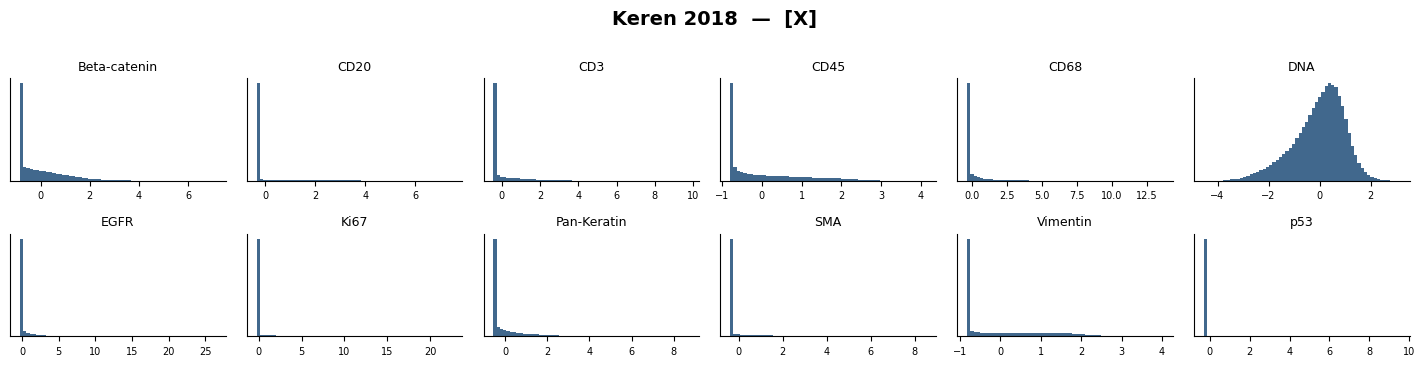

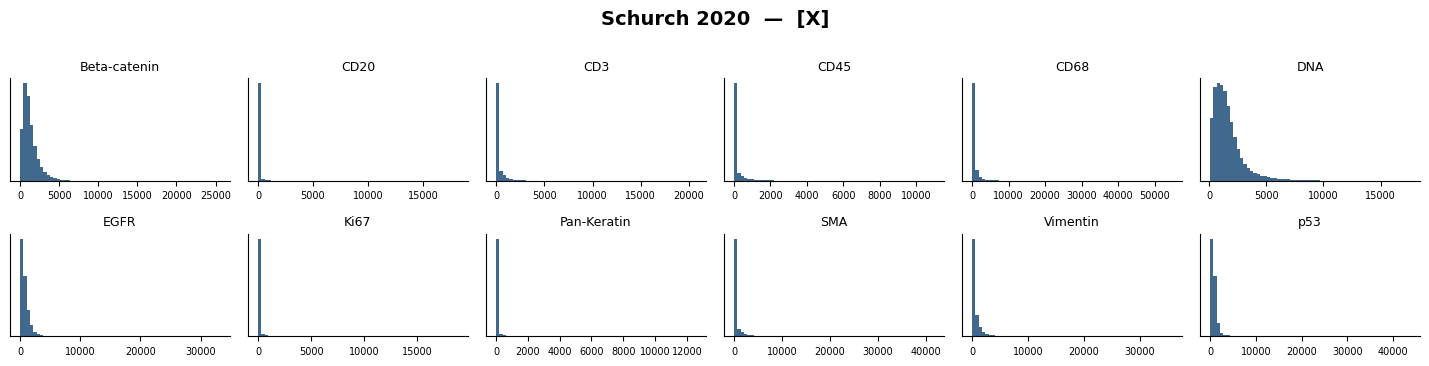

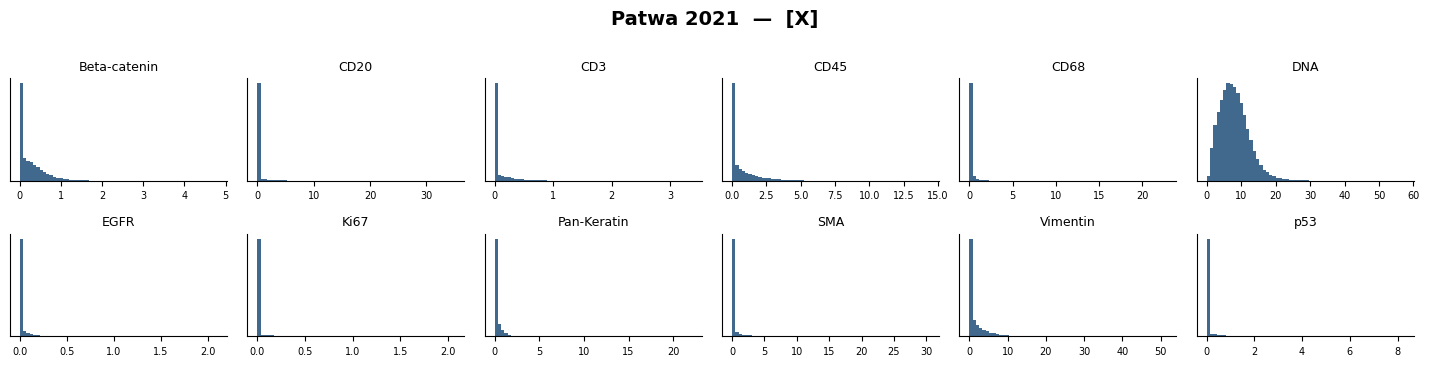

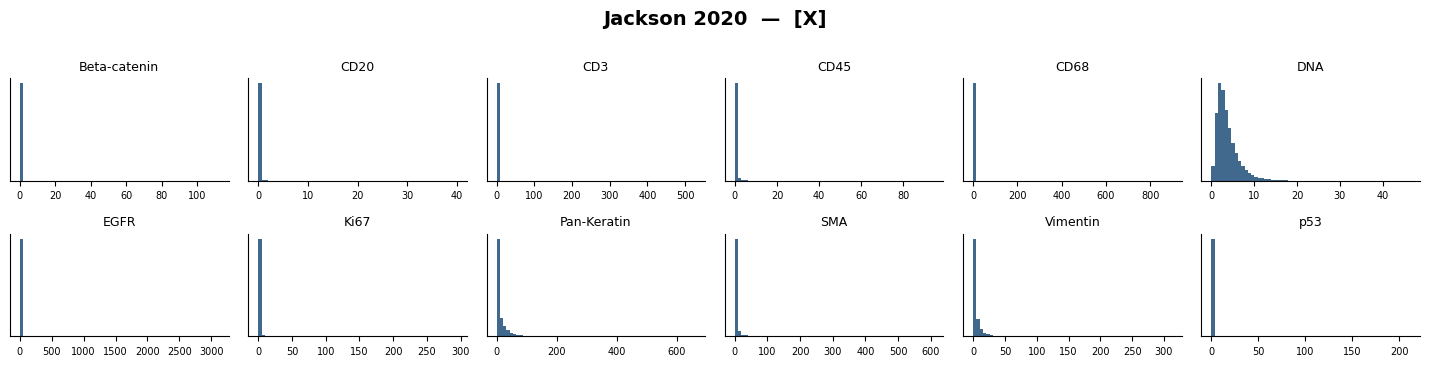

In [4]:
for name, _, _ in DATASETS:
    plot_marker_distributions(adatas[name], layer=None, markers=SHARED)

## 2. Step 1 — Cell Size Normalization

Only **Schurch** is both raw-count *and* has a cell-area column (`obs["size"]`), so it is
the only dataset normalized here (`X / size` → `layers["size_norm"]`). Patwa was already
area-normalized upstream; Keren and Jackson arrive pre-transformed.

In [5]:
apply_size_norm(adatas['Schurch 2020'], size_col='size')

expression_stats_table([
    {**expression_stats(adatas['Schurch 2020'], layer=None),       'dataset': 'Schurch 2020', 'layer': 'X (raw)'},
    {**expression_stats(adatas['Schurch 2020'], layer='size_norm'), 'dataset': 'Schurch 2020', 'layer': 'size_norm'},
])

dataset,layer,NaN%,min,p1,median,p99,max,Neg%,Zero%
Schurch 2020,X (raw),0.0%,0.000,0.000,71.164,4277.354,54776.695,0.0%,16.7%
Schurch 2020,size_norm,0.0%,0.000,0.000,0.015,1.957,91.447,0.0%,16.7%


### 2a. Schurch cofactor sweep (on size-normalized values)

The earlier ~150 cofactor was an artifact of applying arcsinh to *raw summed counts*.
After size normalization the values are per-pixel means (median ≈ 0.015), so the
appropriate cofactor is small. The sweep below confirms cofactor ≈ 0.5 gives a
well-spread distribution (final range is set by step 4, so the cofactor only governs
shape).

In [6]:
sn = adatas['Schurch 2020'].layers['size_norm']
v = np.asarray(sn, dtype=float).flatten()
v = v[v > 0]

rows = []
for cofactor in [0.1, 0.2, 0.5, 1, 2, 5]:
    t = np.arcsinh(v / cofactor)
    rows.append(dict(cofactor=cofactor,
                     median=round(float(np.median(t)), 3),
                     p99=round(float(np.percentile(t, 99)), 3),
                     max=round(float(t.max()), 3)))
display(pd.DataFrame(rows).style.hide(axis='index').set_properties(**{'text-align': 'left'}))

cofactor,median,p99,max
0.100000,0.249000,3.781000,7.511000
0.200000,0.126000,3.089000,6.818000
0.500000,0.050000,2.184000,5.902000
1.000000,0.025000,1.526000,5.209000
2.000000,0.013000,0.947000,4.516000
5.000000,0.005000,0.425000,3.600000


## 3. Step 2 — Arcsinh Transformation

`prepare_exprs()` brings every dataset to the common `layers["exprs"]` checkpoint:
Schurch sources from `size_norm` (cofactor 0.5), Patwa applies `arcsinh(X/5)`, Keren
copies its already-arcsinh `X`, Jackson reuses its publisher `exprs` layer.

In [7]:
post_records = []
for name, _, cfg in DATASETS:
    prepare_exprs(adatas[name], cfg)
    s = expression_stats(adatas[name], layer='exprs')
    s.update(dataset=name, layer='exprs')
    post_records.append(s)
    print(f'{name:14s} → {adatas[name].uns["preprocessing"]}')

expression_stats_table(post_records)

Keren 2018     → {'exprs_source': 'X (pre-transformed)', 'arcsinh_cofactor': None}
Schurch 2020   → {'exprs_source': 'X / size → arcsinh', 'arcsinh_cofactor': 0.5, 'size_norm': True}
Patwa 2021     → {'exprs_source': 'X → arcsinh', 'arcsinh_cofactor': 5, 'size_norm': False}
Jackson 2020   → {'exprs_source': 'pre-existing arcsinh', 'arcsinh_cofactor': None}


dataset,layer,NaN%,min,p1,median,p99,max,Neg%,Zero%
Keren 2018,exprs,0.0%,-4.452,-1.405,-0.231,3.890,67.208,77.9%,0.0%
Schurch 2020,exprs,0.0%,0.000,0.000,0.030,2.074,5.902,0.0%,16.7%
Patwa 2021,exprs,0.0%,0.000,0.000,0.000,2.427,4.598,0.0%,52.4%
Jackson 2020,exprs,4.6%,0.000,0.000,0.533,4.259,8.011,0.0%,2.8%


## 4. Step 3 — Winsorization (99.9th percentile, per marker)

Cap each marker at its 99.9th percentile to suppress antibody-aggregate outliers.
Applied **in place** on `layers["exprs"]`. The `max` column should drop while `p99`
stays put.

In [8]:
wins_records = []
for name, _, _ in DATASETS:
    apply_winsorize(adatas[name], layer='exprs', pct=99.9)
    s = expression_stats(adatas[name], layer='exprs')
    s.update(dataset=name, layer='exprs (winsorized)')
    wins_records.append(s)

expression_stats_table(wins_records)

dataset,layer,NaN%,min,p1,median,p99,max,Neg%,Zero%
Keren 2018,exprs (winsorized),0.0%,-4.452,-1.405,-0.231,3.890,19.163,77.9%,0.0%
Schurch 2020,exprs (winsorized),0.0%,0.000,0.000,0.030,2.067,4.389,0.0%,16.7%
Patwa 2021,exprs (winsorized),0.0%,0.000,0.000,0.000,2.426,4.218,0.0%,52.4%
Jackson 2020,exprs (winsorized),4.6%,0.000,0.000,0.533,4.250,6.615,0.0%,2.8%


## 5. Step 4 — 0–1 Normalization (per marker)

Per-marker min-max scaling of the winsorized `exprs` → `layers["exprs_norm"]`, the final
modeling layer. All markers in all datasets now share the `[0, 1]` range.

In [9]:
norm_records = []
for name, _, _ in DATASETS:
    apply_minmax(adatas[name], layer='exprs', target_layer='exprs_norm')
    s = expression_stats(adatas[name], layer='exprs_norm')
    s.update(dataset=name, layer='exprs_norm')
    norm_records.append(s)

expression_stats_table(norm_records)

dataset,layer,NaN%,min,p1,median,p99,max,Neg%,Zero%
Keren 2018,exprs_norm,0.0%,0.000,0.000,0.000,0.809,1.000,0.0%,62.8%
Schurch 2020,exprs_norm,0.0%,0.000,0.000,0.017,0.635,1.000,0.0%,16.7%
Patwa 2021,exprs_norm,0.0%,0.000,0.000,0.000,0.729,1.000,0.0%,52.4%
Jackson 2020,exprs_norm,4.6%,0.000,0.000,0.171,0.827,1.000,0.0%,2.8%


## 6. Processed distributions — shared markers (POST)

Same per-dataset grids as section 1b, now on the final `exprs_norm` layer. Distributions
should be on a common `[0, 1]` scale with comparable shapes across platforms — the visual
confirmation that preprocessing harmonized the datasets.

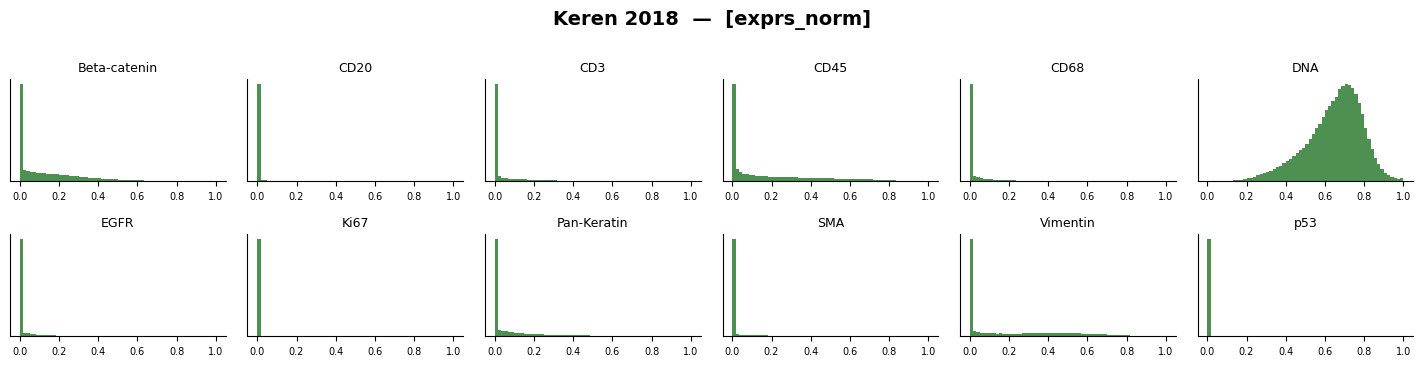

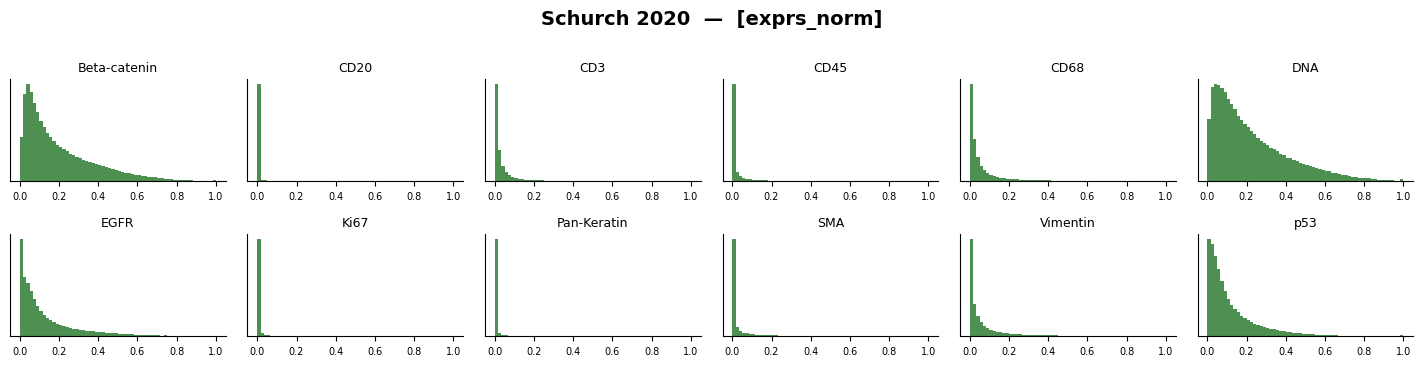

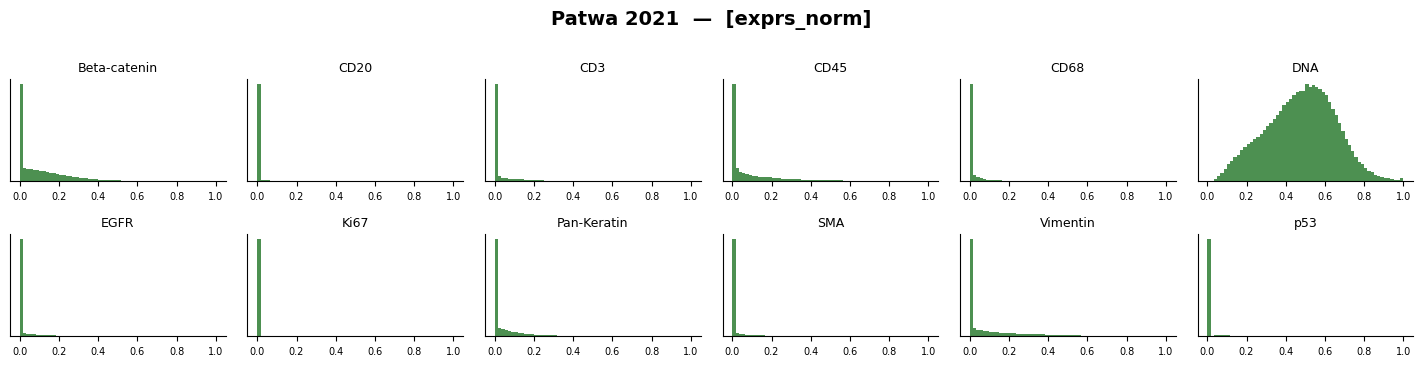

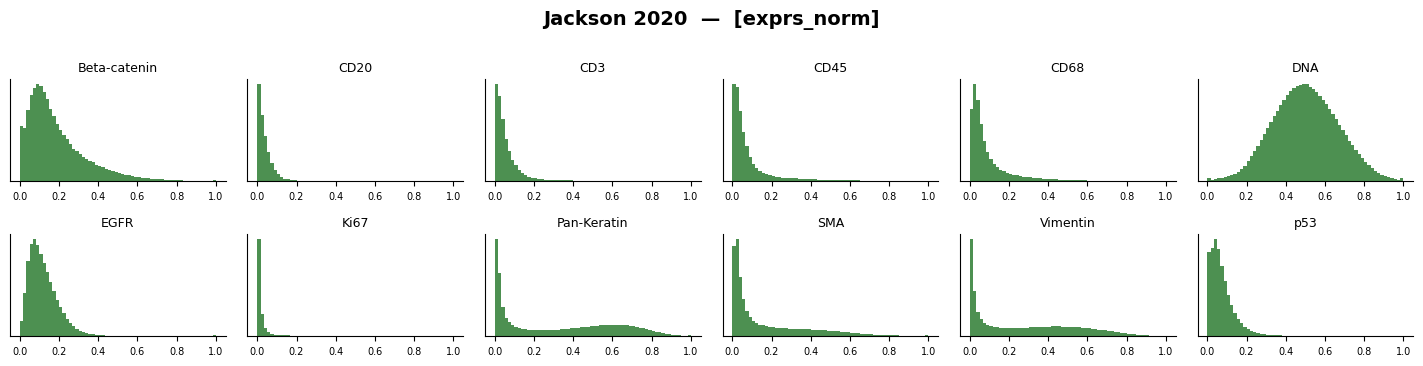

In [10]:
for name, _, _ in DATASETS:
    plot_marker_distributions(adatas[name], layer='exprs_norm', markers=SHARED, color="#2e7d32")

### 6a. Single-marker cross-dataset check — Ki67

Ki67 side-by-side across datasets, raw `X` vs final `exprs_norm`.

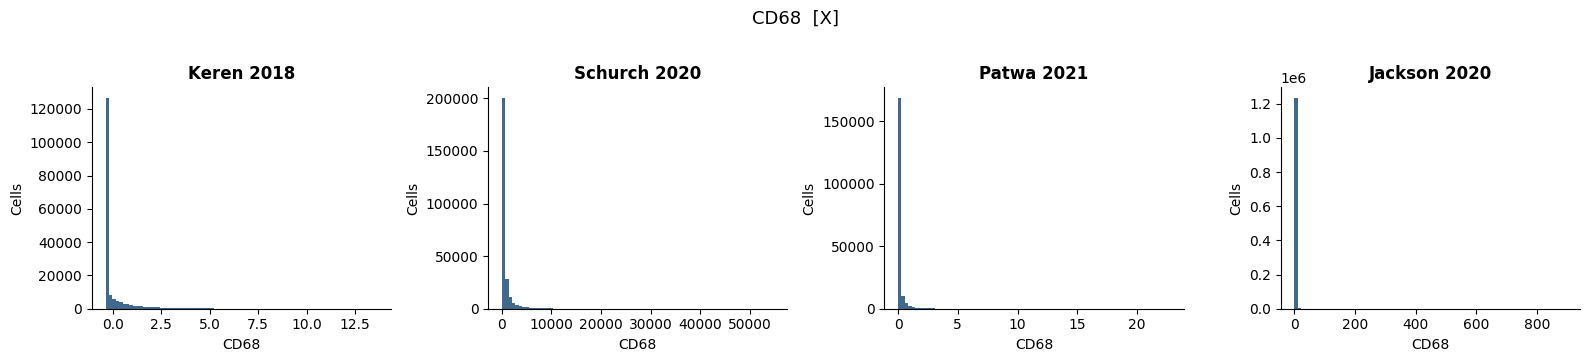

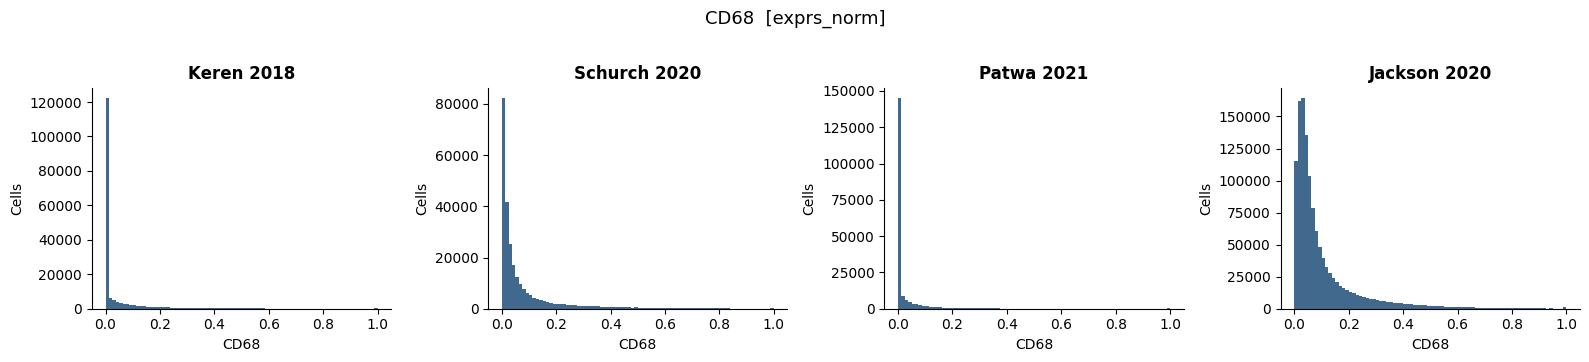

In [13]:
marker_distributions(adatas, marker='Ki67', layer=None)
marker_distributions(adatas, marker='Ki67', layer='exprs_norm')

## 7. Final provenance summary

In [12]:
for name, _, _ in DATASETS:
    a = adatas[name]
    print(f'{name:14s} layers={list(a.layers.keys())}\n'
          f'{"":14s} preprocessing={a.uns["preprocessing"]}\n')

Keren 2018     layers=['exprs', 'exprs_norm']
               preprocessing={'exprs_source': 'X (pre-transformed)', 'arcsinh_cofactor': None}

Schurch 2020   layers=['size_norm', 'exprs', 'exprs_norm']
               preprocessing={'exprs_source': 'X / size → arcsinh', 'arcsinh_cofactor': 0.5, 'size_norm': True}

Patwa 2021     layers=['positivity', 'exprs', 'exprs_norm']
               preprocessing={'exprs_source': 'X → arcsinh', 'arcsinh_cofactor': 5, 'size_norm': False}

Jackson 2020   layers=['exprs', 'quant_norm', 'exprs_norm']
               preprocessing={'exprs_source': 'pre-existing arcsinh', 'arcsinh_cofactor': None}



## 8. (Plan only) Pre/Post Joint UMAP — raw vs processed

A strong visual check of batch harmonization is a joint UMAP of all datasets, on the
**shared markers** as features, colored by dataset — computed once on raw `X` and once on
`exprs_norm`. If preprocessing works, raw should show dataset-driven separation that
`exprs_norm` substantially mixes.

**Not implemented here** — >1.6M cells make a naive UMAP costly. Efficient recipe to run
separately:

1. **Subsample** stratified by dataset — e.g. `sc.pp.subsample(a, n_obs=25_000)` per
   dataset (~100k total), so each contributes comparably regardless of size.
2. **Restrict to shared markers**, resolving canonical→raw per dataset, and build one
   concatenated `AnnData` (`ad.concat([...], join='inner', label='dataset')`).
3. **Two feature matrices** from the same cells:
   - *raw*: `X` shared-marker columns, z-scored per marker (so raw scale differences
     don't trivially dominate — the fair "before" baseline).
   - *processed*: `exprs_norm` shared-marker columns.
4. **Embed each**: `sc.pp.pca(n_comps=20)` → `sc.pp.neighbors()` → `sc.tl.umap()`.
5. **Plot side by side**: `sc.pl.umap(color='dataset')` for raw vs processed.
6. **Cost control**: cache the subsampled concat to disk; PCA on ~100k × ~12 markers is
   seconds. Optionally quantify mixing with a kBET / iLISI score rather than eyeballing.

This belongs in its own notebook/script (joint embedding + Harmony) once the cofactor and
winsorization choices here are locked.